In [3]:
#!git clone https://github.com/lqiang67/rectified-flow.git
%cd rectified-flow/

/Users/saptarshiroy/Documents/GitHub/Low-dim-RF/rectified-flow


In [39]:
import torch
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

import torch.distributions as dist
import gmm 
from rectified_flow.utils import set_seed
from rectified_flow.utils import visualize_2d_trajectories_plotly
from rectified_flow.datasets.toy_gmm import TwoPointGMM

from rectified_flow.rectified_flow import RectifiedFlow
from rectified_flow.models.toy_mlp import MLPVelocityConditioned, MLPVelocity
from metric import calculate_discriminative_tv_qda

set_seed(0)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Setting parameters

In [40]:
from sklearn.datasets import make_moons
from data_generator import generate_data
from RFsampler_modules import geom_timegrid_generator, lin_timegrid_generator, MytrueEulerSampler
from RFmodules import VelocityNet

DIMENSIONS = [int(i) for i in np.logspace(1, 2.9, num = 10)]
#####################################
n_samples = 50000
INPUT_DIM = 800
RANK = 8
CENTER = torch.ones(INPUT_DIM) * 8.0
TYPE = 'low_rank_Gaussian'  # 'low_rank_Gaussian' or 'two_moons'

NUM_STEPS = 100 # Number of time steps for sampling
NUM_SAMPLES = 2000 # Number of samples to Generate
#####################################

TV_geom_list = []
TV_lin_list = []



In [41]:
for INPUT_DIM in DIMENSIONS:
    CENTER = torch.ones(INPUT_DIM) * 8.0
    

    # Original target distribution
    D1 = generate_data(TYPE, n_samples, INPUT_DIM, RANK, CENTER, device=device)

    
    for rounds in tqdm(range(10), desc=f"DIM {INPUT_DIM}"):
        TV_geom = 0
        TV_lin = 0
        # print(f"Dimension: {INPUT_DIM}, Round: {rounds+1}")

        # generate data
        pi_0 = dist.MultivariateNormal(torch.zeros(INPUT_DIM, device=device), torch.eye(INPUT_DIM, device=device))
        D0 = pi_0.sample([n_samples])  

        
        
        # Fluff RF model
        straight_rf = RectifiedFlow(
            data_shape=(INPUT_DIM,),
            velocity_field=VelocityNet(INPUT_DIM, h_dim=128).to(device), # MLPVelocity(INPUT_DIM, hidden_sizes = [128] * 6).to(device)
            interp="straight",
            source_distribution=pi_0,
            device=device,
        )

        # generate trajectories using true velocity field
        
        
        true_euler_sampler_lin = MytrueEulerSampler( k = RANK, d = INPUT_DIM, CENTER= CENTER,
            time_grid = lin_timegrid_generator(NUM_STEPS),
            rectified_flow = straight_rf,
            num_samples= NUM_SAMPLES,
        )

        true_euler_sampler_geom = MytrueEulerSampler( k = RANK, d = INPUT_DIM, CENTER= CENTER,
            time_grid = geom_timegrid_generator(NUM_STEPS, delta=1/max(INPUT_DIM, NUM_STEPS)),
            rectified_flow = straight_rf,
            num_samples= NUM_SAMPLES,
        )

        true_traj1_geom = true_euler_sampler_geom.sample_loop(seed=100)
        true_traj1_lin = true_euler_sampler_lin.sample_loop(seed=100)


        # Caluclate TV-QDA between generated samples and real data samples at a certain time step
        geom_time_grid = geom_timegrid_generator(NUM_STEPS, delta=1/max(INPUT_DIM, NUM_STEPS))
        lin_time_grid = lin_timegrid_generator(NUM_STEPS)
        pos  = 2  # Position in the time grid to evaluate
        blurred_Real_Data_geom = D1[:NUM_SAMPLES] * geom_time_grid[-pos] + D0[:NUM_SAMPLES] * (1 - geom_time_grid[-pos])
        blurred_Real_Data_lin = D1[:NUM_SAMPLES] * lin_time_grid[-pos] + D0[:NUM_SAMPLES] * (1 - lin_time_grid[-pos])
        blurred_Real_Data_geom = blurred_Real_Data_geom.cpu().numpy()  # Real data samples from distribution p_1
        blurred_Real_Data_lin = blurred_Real_Data_lin.cpu().numpy()  # Real data samples from distribution p_1
        Gen_Data_geom = true_traj1_geom.trajectories[-pos].cpu().numpy()  # Generated data samples from geometry time grid
        Gen_Data_lin = true_traj1_lin.trajectories[-pos].cpu().numpy()  # Generated data samples from linear time grid
        tv_qda_geom = calculate_discriminative_tv_qda(blurred_Real_Data_geom, Gen_Data_geom)
        tv_qda_lin = calculate_discriminative_tv_qda(blurred_Real_Data_geom, Gen_Data_lin)

        TV_geom += tv_qda_geom
        TV_lin += tv_qda_lin

    TV_geom_list.append(np.mean(TV_geom))
    TV_lin_list.append(np.mean(TV_lin))

DIM 10:   0%|          | 0/10 [00:00<?, ?it/s]

DIM 16:   0%|          | 0/10 [00:00<?, ?it/s]

DIM 26:   0%|          | 0/10 [00:00<?, ?it/s]

DIM 42:   0%|          | 0/10 [00:00<?, ?it/s]

DIM 69:   0%|          | 0/10 [00:00<?, ?it/s]

DIM 113:   0%|          | 0/10 [00:00<?, ?it/s]

DIM 184:   0%|          | 0/10 [00:00<?, ?it/s]

DIM 300:   0%|          | 0/10 [00:00<?, ?it/s]

DIM 488:   0%|          | 0/10 [00:00<?, ?it/s]

DIM 794:   0%|          | 0/10 [00:00<?, ?it/s]

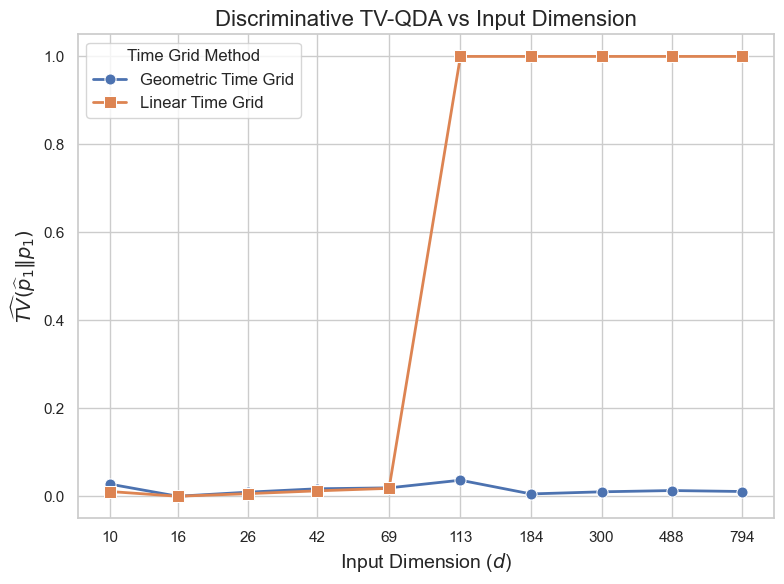

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
# -----------------------------------------------------------------

# Set a seaborn style for better aesthetics (e.g., 'whitegrid' or 'darkgrid')
sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 6))

# 1. Plot the Geometric Time Grid data using sns.lineplot
# 'marker' and 'markersize' can be used like in matplotlib
sns.lineplot(
    x=DIMENSIONS,
    y=TV_geom_list,
    marker='o',
    label='Geometric Time Grid',
    markersize=8,
    linewidth=2
)

# 2. Plot the Linear Time Grid data using sns.lineplot
sns.lineplot(
    x=DIMENSIONS,
    y=TV_lin_list,
    marker='s',
    label='Linear Time Grid',
    markersize=8,
    linewidth=2
)

# 3. Apply the scales and labels
plt.xscale('log')
plt.xticks(DIMENSIONS, labels=[str(d) for d in DIMENSIONS])
# If you decide to re-enable the log scale for the Y-axis:
# plt.yscale('log')

plt.xlabel('Input Dimension ($d$)', fontsize=14)
# Use the raw string (r'...') to correctly render the LaTeX math expression
plt.ylabel(r'$\widehat{TV}(\widehat{p}_1 \Vert p_1)$', fontsize=14)

plt.legend(fontsize=12, title='Time Grid Method')
plt.title('Discriminative TV-QDA vs Input Dimension', fontsize=16)

# Use plt.tight_layout() to ensure labels and title fit within the figure area
plt.tight_layout()


plt.savefig('assets/low_rank_TV_vs_dimension.pdf', dpi=300)
plt.show()

# Plotting KL distance

In [54]:
from metric import kl_divergence_gaussians

kl_geom_list = []
kl_lin_list = []

for INPUT_DIM in DIMENSIONS:
    CENTER = torch.ones(INPUT_DIM) * 8.0
    

    # Original target distribution
    D1 = generate_data(TYPE, n_samples, INPUT_DIM, RANK, CENTER, device=device)

    
    for rounds in tqdm(range(10), desc=f"DIM {INPUT_DIM}"):
        kl_geom = 0
        kl_lin = 0
        # print(f"Dimension: {INPUT_DIM}, Round: {rounds+1}")

        # generate data
        pi_0 = dist.MultivariateNormal(torch.zeros(INPUT_DIM, device=device), torch.eye(INPUT_DIM, device=device))
        D0 = pi_0.sample([n_samples])  

        
        
        # Fluff RF model
        straight_rf = RectifiedFlow(
            data_shape=(INPUT_DIM,),
            velocity_field=VelocityNet(INPUT_DIM, h_dim=128).to(device), # MLPVelocity(INPUT_DIM, hidden_sizes = [128] * 6).to(device)
            interp="straight",
            source_distribution=pi_0,
            device=device,
        )

        # generate trajectories using true velocity field
        
        
        true_euler_sampler_lin = MytrueEulerSampler( k = RANK, d = INPUT_DIM, CENTER= CENTER,
            time_grid = lin_timegrid_generator(NUM_STEPS),
            rectified_flow = straight_rf,
            num_samples= NUM_SAMPLES,
        )

        true_euler_sampler_geom = MytrueEulerSampler( k = RANK, d = INPUT_DIM, CENTER= CENTER,
            time_grid = geom_timegrid_generator(NUM_STEPS, delta=1/max(INPUT_DIM, NUM_STEPS)),
            rectified_flow = straight_rf,
            num_samples= NUM_SAMPLES,
        )

        true_traj1_geom = true_euler_sampler_geom.sample_loop(seed=100)
        true_traj1_lin = true_euler_sampler_lin.sample_loop(seed=100)


        # Caluclate TV-QDA between generated samples and real data samples at a certain time step
        geom_time_grid = geom_timegrid_generator(NUM_STEPS, delta=1/max(INPUT_DIM, NUM_STEPS))
        lin_time_grid = lin_timegrid_generator(NUM_STEPS)
        pos  = 2  # Position in the time grid to evaluate
        blurred_Real_Data_geom = D1[:NUM_SAMPLES] * geom_time_grid[-pos] + D0[:NUM_SAMPLES] * (1 - geom_time_grid[-pos])
        blurred_Real_Data_lin = D1[:NUM_SAMPLES] * lin_time_grid[-pos] + D0[:NUM_SAMPLES] * (1 - lin_time_grid[-pos])
        blurred_Real_Data_geom = blurred_Real_Data_geom.cpu().numpy()  # Real data samples from distribution p_1
        blurred_Real_Data_lin = blurred_Real_Data_lin.cpu().numpy()  # Real data samples from distribution p_1
        Gen_Data_geom = true_traj1_geom.trajectories[-pos].cpu().numpy()  # Generated data samples from geometry time grid
        Gen_Data_lin = true_traj1_lin.trajectories[-pos].cpu().numpy()  # Generated data samples from linear time grid

        mean_real_geom = np.mean(blurred_Real_Data_geom, axis=0)
        cov_real_geom = np.cov(blurred_Real_Data_geom, rowvar=False)
        # mean_real_lin = np.mean(blurred_Real_Data_lin, axis=0)
        # cov_real_lin = np.cov(blurred_Real_Data_lin, rowvar=False)
        mean_gen_geom = np.mean(Gen_Data_geom, axis=0)
        cov_gen_geom = np.cov(Gen_Data_geom, rowvar=False)
        mean_gen_lin = np.mean(Gen_Data_lin, axis=0)
        cov_gen_lin = np.cov(Gen_Data_lin, rowvar=False)


        kl_geom = kl_divergence_gaussians(mean_real_geom, cov_real_geom, mean_gen_geom, cov_gen_geom)
        kl_lin = kl_divergence_gaussians(mean_real_geom, cov_real_geom, mean_gen_lin, cov_gen_lin)

        kl_geom += kl_geom
        kl_lin += kl_lin
    kl_geom_list.append(np.mean(kl_geom))
    kl_lin_list.append(np.mean(kl_lin))

DIM 10:   0%|          | 0/10 [00:00<?, ?it/s]

DIM 16:   0%|          | 0/10 [00:00<?, ?it/s]

DIM 26:   0%|          | 0/10 [00:00<?, ?it/s]

DIM 42:   0%|          | 0/10 [00:00<?, ?it/s]

DIM 69:   0%|          | 0/10 [00:00<?, ?it/s]

DIM 113:   0%|          | 0/10 [00:00<?, ?it/s]

DIM 184:   0%|          | 0/10 [00:00<?, ?it/s]

DIM 300:   0%|          | 0/10 [00:00<?, ?it/s]

DIM 488:   0%|          | 0/10 [00:00<?, ?it/s]

DIM 794:   0%|          | 0/10 [00:00<?, ?it/s]

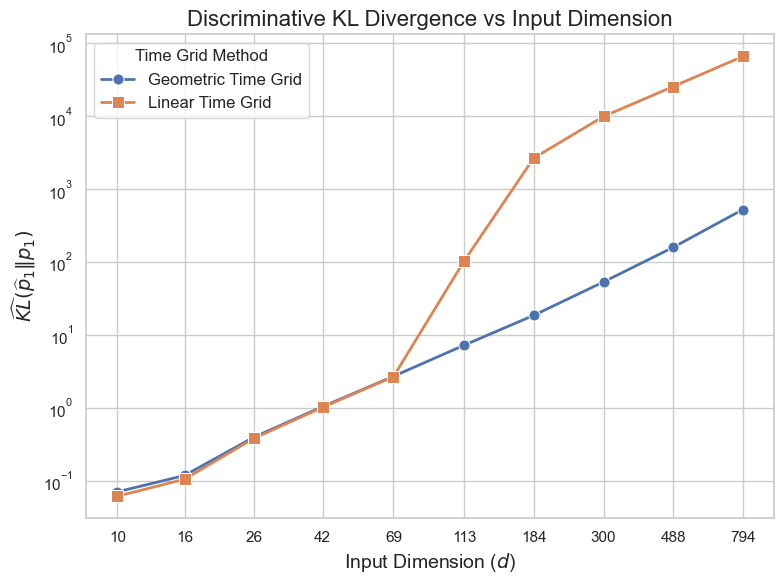

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
# -----------------------------------------------------------------

# Set a seaborn style for better aesthetics (e.g., 'whitegrid' or 'darkgrid')
sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 6))

# 1. Plot the Geometric Time Grid data using sns.lineplot
# 'marker' and 'markersize' can be used like in matplotlib
sns.lineplot(
    x=DIMENSIONS,
    y=kl_geom_list,
    marker='o',
    label='Geometric Time Grid',
    markersize=8,
    linewidth=2
)

# 2. Plot the Linear Time Grid data using sns.lineplot
sns.lineplot(
    x=DIMENSIONS,
    y=kl_lin_list,
    marker='s',
    label='Linear Time Grid',
    markersize=8,
    linewidth=2
)

# 3. Apply the scales and labels
plt.xscale('log')
plt.xticks(DIMENSIONS, labels=[str(d) for d in DIMENSIONS])
# If you decide to re-enable the log scale for the Y-axis:
plt.yscale('log')

plt.xlabel('Input Dimension ($d$)', fontsize=14)
# Use the raw string (r'...') to correctly render the LaTeX math expression
plt.ylabel(r'$\widehat{KL}(\widehat{p}_1 \Vert p_1)$', fontsize=14)

plt.legend(fontsize=12, title='Time Grid Method')
plt.title('Discriminative KL Divergence vs Input Dimension', fontsize=16)

# Use plt.tight_layout() to ensure labels and title fit within the figure area
plt.tight_layout()


plt.savefig('assets/low_rank_KL_vs_dimension.pdf', dpi=300)
plt.show()

In [53]:
kl_lin_list

[0.0713576150516797,
 0.11965485693296785,
 0.4013382525527156,
 1.0499304036753117,
 2.733464210891114,
 7.280513255235078,
 18.703854403605504,
 53.759916834749106,
 159.71128196666155,
 525.9676162427136]